In [1]:
# ==========================================================
# LunaVision-AI
# Stage 4C
# U-Net + L1 + SSIM + Perceptual Loss
# ==========================================================

# Install required package
!pip install -q pytorch-msssim

import numpy as np
import pandas as pd
import os

print("=== Dataset Structure Summary ===")

for dirname, dirnames, filenames in os.walk('/kaggle/input'):

    visible_files = [
        f for f in filenames
        if not f.startswith('.')
    ]

    if visible_files:

        print(f"📁 {dirname}")
        print(f"   └── Contains {len(visible_files)} files\n")

=== Dataset Structure Summary ===
📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset
   └── Contains 1 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distorted images/368x368
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distorted images/92x92
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/368x368
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/92x92
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/720x480
   └── Contains 9500 files



In [2]:
!pip install pytorch-msssim -q

In [3]:
# ==========================================================
# Stage 4C - Imports
# U-Net + L1 + SSIM + Perceptual Loss
# ==========================================================

import numpy as np
import pandas as pd
import os
import gc

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image

import torchvision.transforms as transforms
import torchvision.models as models

from pytorch_msssim import ssim

import matplotlib.pyplot as plt

from tqdm import tqdm

In [5]:
# ==========================================================
# Stage 4C - Device Configuration
# ==========================================================

gc.collect()
torch.cuda.empty_cache()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 50)
print("LunaVision-AI")
print("Stage 4C")
print("=" * 50)
print(f"Running on: {device}")
print("=" * 50)

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

LunaVision-AI
Stage 4C
Running on: cuda
GPU: Tesla T4


In [7]:
# ==========================================================
# Stage 4C - Dataset Class
# ==========================================================

from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import torchvision.transforms as transforms

class LunarDataset(Dataset):

    def __init__(self, distorted_dir, clean_dir):

        self.distorted_dir = Path(distorted_dir)
        self.clean_dir = Path(clean_dir)

        self.image_names = sorted(

            [
                img.name

                for img in self.distorted_dir.glob("*")

                if img.suffix.lower() in [
                    ".jpg",
                    ".jpeg",
                    ".png"
                ]
            ]

        )

        self.transform = transforms.Compose([

            transforms.ToTensor()

        ])

    def __len__(self):

        return len(self.image_names)

    def __getitem__(self, idx):

        image_name = self.image_names[idx]

        distorted = Image.open(

            self.distorted_dir / image_name

        ).convert("RGB")

        clean = Image.open(

            self.clean_dir / image_name

        ).convert("RGB")

        distorted = self.transform(distorted)

        clean = self.transform(clean)

        return distorted, clean

In [8]:
# ==========================================================
# Stage 4C - Dataset and DataLoader
# ==========================================================

distorted_path = "/kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distorted images/368x368"

clean_path = "/kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/368x368"

train_dataset = LunarDataset(

    distorted_dir=distorted_path,

    clean_dir=clean_path

)

train_loader = DataLoader(

    train_dataset,

    batch_size=4,          # Reduced from 8 for Stage 4C

    shuffle=True,

    num_workers=2,

    pin_memory=True

)

print("="*50)

print("Stage 4C Dataset Loaded")

print("="*50)

print(f"Training Images : {len(train_dataset)}")

print(f"Batch Size      : 4")

print(f"Total Batches   : {len(train_loader)}")

print("="*50)

Stage 4C Dataset Loaded
Training Images : 9500
Batch Size      : 4
Total Batches   : 2375


In [9]:
# ==========================================================
# Stage 4C - Double Convolution Block
# ==========================================================

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True)

        )

    def forward(self, x):

        return self.conv(x)

In [10]:
# ==========================================================
# Stage 4C - U-Net Architecture
# ==========================================================

class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        # ======================
        # Encoder
        # ======================

        self.down1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        # ======================
        # Bottleneck
        # ======================

        self.middle = DoubleConv(128, 256)

        # ======================
        # Decoder
        # ======================

        self.up1 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.conv1 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.conv2 = DoubleConv(
            128,
            64
        )

        # ======================
        # Output Layer
        # ======================

        self.final = nn.Conv2d(
            64,
            3,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        x1 = self.down1(x)

        x2 = self.down2(
            self.pool1(x1)
        )

        # Bottleneck
        x3 = self.middle(
            self.pool2(x2)
        )

        # Decoder
        x = self.up1(x3)

        x = torch.cat(
            [x, x2],
            dim=1
        )

        x = self.conv1(x)

        x = self.up2(x)

        x = torch.cat(
            [x, x1],
            dim=1
        )

        x = self.conv2(x)

        # Final Output
        output = torch.sigmoid(
            self.final(x)
        )

        return output

In [11]:
# ==========================================================
# Stage 4C Loss Functions
# L1 + SSIM + Perceptual Loss
# ==========================================================

class VGGPerceptualLoss(nn.Module):

    def __init__(self):

        super().__init__()

        vgg = models.vgg16(
            weights=models.VGG16_Weights.IMAGENET1K_V1
        ).features.eval()

        for param in vgg.parameters():
            param.requires_grad = False

        self.vgg = vgg[:16]

        self.l1 = nn.L1Loss()

        self.register_buffer(
            "mean",
            torch.tensor([0.485,0.456,0.406]).view(1,3,1,1)
        )

        self.register_buffer(
            "std",
            torch.tensor([0.229,0.224,0.225]).view(1,3,1,1)
        )

    def forward(self,prediction,target):

        prediction = (prediction-self.mean)/self.std
        target = (target-self.mean)/self.std

        pred_features = self.vgg(prediction)

        with torch.no_grad():

            target_features = self.vgg(target)

        return self.l1(
            pred_features,
            target_features
        )


class RestorationLoss(nn.Module):

    def __init__(

        self,

        w_l1=1.0,

        w_ssim=1.0,

        w_perceptual=0.05

    ):

        super().__init__()

        self.l1 = nn.L1Loss()

        self.perceptual = VGGPerceptualLoss()

        self.w_l1 = w_l1

        self.w_ssim = w_ssim

        self.w_perceptual = w_perceptual

    def forward(self,prediction,target):

        l1_loss = self.l1(
            prediction,
            target
        )

        ssim_loss = 1-ssim(
            prediction,
            target,
            data_range=1,
            size_average=True
        )

        perceptual_loss = self.perceptual(
            prediction,
            target
        )

        total_loss = (

            self.w_l1*l1_loss

            +

            self.w_ssim*ssim_loss

            +

            self.w_perceptual*perceptual_loss

        )

        return total_loss,{

            "L1":l1_loss.item(),

            "SSIM":ssim_loss.item(),

            "Perceptual":perceptual_loss.item()

        }

In [12]:
# ==========================================================
# Stage 4C Configuration
# ==========================================================

model = UNet().to(device)

criterion = RestorationLoss(

    w_l1=1.0,

    w_ssim=1.0,

    w_perceptual=0.05

).to(device)

optimizer = optim.Adam(

    model.parameters(),

    lr=0.0005

)

print("="*60)

print("Stage 4C Configuration")

print("="*60)

print("Model        : U-Net")

print("Loss Function: L1 + SSIM + Perceptual")

print("Optimizer    : Adam")

print("Learning Rate: 0.0005")

print("Batch Size   : 4")

print("="*60)

print(model)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 207MB/s]  


Stage 4C Configuration
Model        : U-Net
Loss Function: L1 + SSIM + Perceptual
Optimizer    : Adam
Learning Rate: 0.0005
Batch Size   : 4
UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (middle): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1):

In [13]:
# ==========================================================
# Stage 4C Training History
# ==========================================================

train_losses = []

l1_history = []

ssim_history = []

perceptual_history = []

In [14]:
# ==========================================================
# Stage 4C Training
# ==========================================================

epochs = 10

print("\nStarting Stage 4C Training...\n")

for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    running_l1 = 0.0
    running_ssim = 0.0
    running_perceptual = 0.0

    progress = tqdm(train_loader)

    for distorted, clean in progress:

        distorted = distorted.to(device)
        clean = clean.to(device)

        prediction = model(distorted)

        loss, parts = criterion(
            prediction,
            clean
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        running_l1 += parts["L1"]

        running_ssim += parts["SSIM"]

        running_perceptual += parts["Perceptual"]

        progress.set_description(
            f"Epoch {epoch+1}/{epochs}"
        )

        progress.set_postfix(
            Total=f"{loss.item():.4f}",
            L1=f"{parts['L1']:.4f}",
            SSIM=f"{parts['SSIM']:.4f}",
            Perc=f"{parts['Perceptual']:.4f}"
        )

    epoch_loss = running_loss / len(train_loader)

    epoch_l1 = running_l1 / len(train_loader)

    epoch_ssim = running_ssim / len(train_loader)

    epoch_perceptual = running_perceptual / len(train_loader)

    train_losses.append(epoch_loss)

    l1_history.append(epoch_l1)

    ssim_history.append(epoch_ssim)

    perceptual_history.append(epoch_perceptual)

    print("="*60)
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Total Loss      : {epoch_loss:.5f}")
    print(f"L1 Loss         : {epoch_l1:.5f}")
    print(f"SSIM Loss       : {epoch_ssim:.5f}")
    print(f"Perceptual Loss : {epoch_perceptual:.5f}")
    print("="*60)

print("\nStage 4C Training Completed!")

print(f"Final Loss = {train_losses[-1]:.5f}")


Starting Stage 4C Training...



Epoch 1/10: 100%|██████████| 2375/2375 [17:06<00:00,  2.31it/s, L1=0.0404, Perc=0.5077, SSIM=0.4202, Total=0.4860]


Epoch 1/10
Total Loss      : 0.57144
L1 Loss         : 0.05417
SSIM Loss       : 0.48752
Perceptual Loss : 0.59484


Epoch 2/10: 100%|██████████| 2375/2375 [17:13<00:00,  2.30it/s, L1=0.0430, Perc=0.6113, SSIM=0.4719, Total=0.5454]


Epoch 2/10
Total Loss      : 0.54518
L1 Loss         : 0.04768
SSIM Loss       : 0.46869
Perceptual Loss : 0.57629


...

Epoch 8/10
Total Loss      : 0.50958
L1 Loss         : 0.04185
SSIM Loss       : 0.43939
Perceptual Loss : 0.56683


Epoch 9/10: 100%|██████████| 2375/2375 [17:15<00:00,  2.29it/s, L1=0.0508, Perc=0.6502, SSIM=0.4995, Total=0.5828]


Epoch 9/10
Total Loss      : 0.50700
L1 Loss         : 0.04149
SSIM Loss       : 0.43714
Perceptual Loss : 0.56737


Epoch 10/10: 100%|██████████| 2375/2375 [17:13<00:00,  2.30it/s, L1=0.0275, Perc=0.3850, SSIM=0.3241, Total=0.3709]

Epoch 10/10
Total Loss      : 0.50413
L1 Loss         : 0.04104
SSIM Loss       : 0.43469
Perceptual Loss : 0.56798

Stage 4C Training Completed!
Final Loss = 0.50413


✓ Stage 4C model saved successfully!


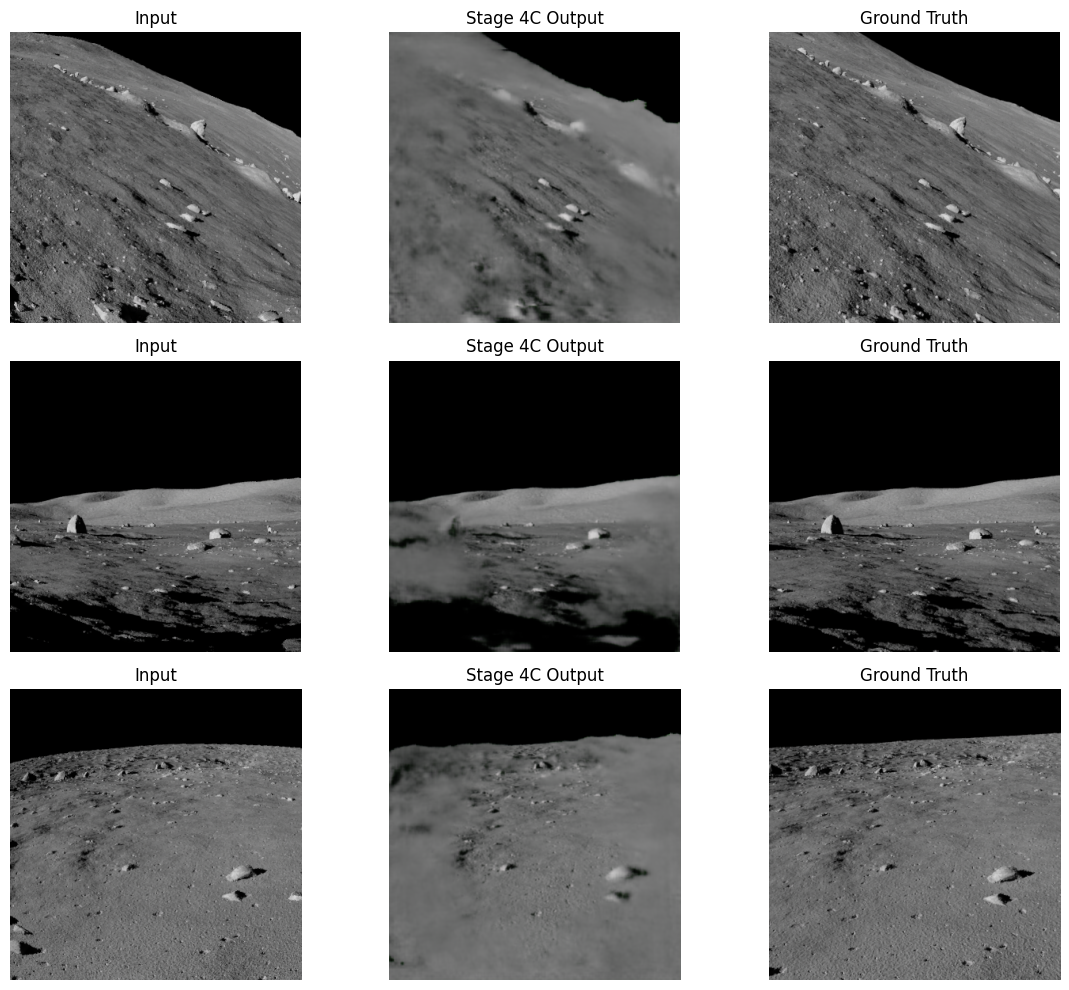

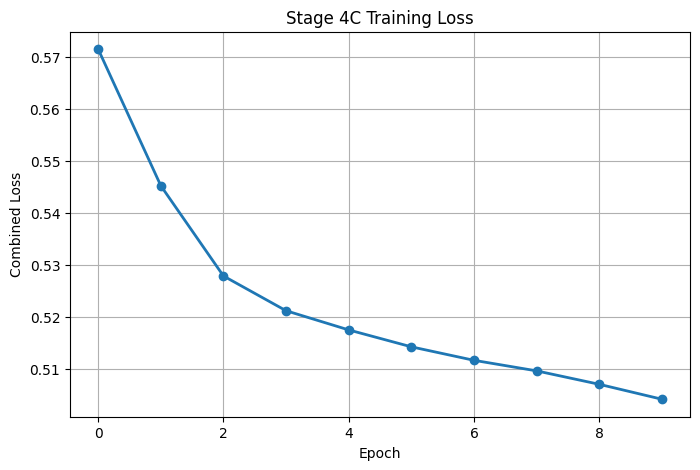

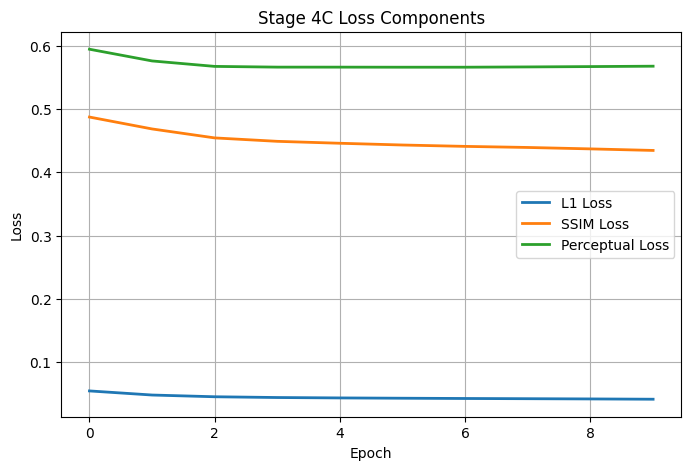

Stage 4C Completed Successfully
Final Combined Loss : 0.50413
Final L1 Loss       : 0.04104
Final SSIM Loss     : 0.43469
Final Perceptual    : 0.56798


In [15]:
# ==========================================================
# Stage 4C - Save Model & Visualize Results
# ==========================================================

# Save trained model
torch.save(
    model.state_dict(),
    "lunavision_stage4C_perceptual.pth"
)

print("✓ Stage 4C model saved successfully!")

# ----------------------------------------------------------
# Visual Comparison
# ----------------------------------------------------------

model.eval()

distorted_batch, clean_batch = next(iter(train_loader))

with torch.no_grad():

    prediction = model(
        distorted_batch.to(device)
    ).cpu()

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i in range(3):

    # Input
    axes[i,0].imshow(
        distorted_batch[i].permute(1,2,0)
    )
    axes[i,0].set_title("Input")
    axes[i,0].axis("off")

    # Prediction
    axes[i,1].imshow(
        prediction[i].permute(1,2,0)
    )
    axes[i,1].set_title("Stage 4C Output")
    axes[i,1].axis("off")

    # Ground Truth
    axes[i,2].imshow(
        clean_batch[i].permute(1,2,0)
    )
    axes[i,2].set_title("Ground Truth")
    axes[i,2].axis("off")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Training Loss Curve
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    marker='o',
    linewidth=2
)

plt.title("Stage 4C Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Combined Loss")

plt.grid(True)

plt.show()

# ----------------------------------------------------------
# Individual Loss Components
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    l1_history,
    label="L1 Loss",
    linewidth=2
)

plt.plot(
    ssim_history,
    label="SSIM Loss",
    linewidth=2
)

plt.plot(
    perceptual_history,
    label="Perceptual Loss",
    linewidth=2
)

plt.title("Stage 4C Loss Components")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

print("="*60)
print("Stage 4C Completed Successfully")
print("="*60)
print(f"Final Combined Loss : {train_losses[-1]:.5f}")
print(f"Final L1 Loss       : {l1_history[-1]:.5f}")
print(f"Final SSIM Loss     : {ssim_history[-1]:.5f}")
print(f"Final Perceptual    : {perceptual_history[-1]:.5f}")
print("="*60)